In [1]:
#import statements
import numpy as np
import rebound
import matplotlib.pyplot as plt
from celmech import Poincare, PoincareHamiltonian
from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict
import symengine as se
from tqdm import tqdm
import heyoka as hy
from scipy import signal
import sympy as sp
import time

from hk_integrator import hk_integrate, ft, pomega_ft, get_pomega, get_ecc

In [2]:
#constants
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

## Direct N-Body WHFast Graphs

In [3]:
########################### TEST PARTICLE CASE ###################################3

sim_test_n_body = rebound.Simulation()
sim_test_n_body.add(m=1, hash = "Sun")
sim_test_n_body.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim_test_n_body.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim_test_n_body.move_to_com()

sat = sim_test_n_body.particles[2]
jup = sim_test_n_body.particles[1]

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat_test_n_body = np.zeros(len(times))
e_sat_test_n_body = np.zeros(len(times))
a_sat_test_n_body = np.zeros(len(times))
p_sat_test_n_body = np.zeros(len(times))

long_peri_j_test_n_body = np.zeros(len(times))
e_j_test_n_body = np.zeros(len(times))
a_j_test_n_body = np.zeros(len(times))
p_j_test_n_body = np.zeros(len(times))

sim_test_n_body.init_megno()
e_i = sim_test_n_body.energy()

for i in tqdm(range(len(times))):
    sim_test_n_body.integrate(times[i])
    
    long_peri_sat_test_n_body[i] = sat.pomega
    e_sat_test_n_body[i] = sat.e
    a_sat_test_n_body[i] = sat.a
    p_sat_test_n_body[i] = sat.P

    long_peri_j_test_n_body[i] = jup.pomega
    e_j_test_n_body[i] = jup.e
    a_j_test_n_body[i] = jup.a
    p_j_test_n_body[i] = jup.P
    
e_f = sim_test_n_body.energy()
m_f = sim_test_n_body.megno()

e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100

print(f'Energy percent change: {e_per: .2e} %')
print(f'Final MEGNO value: {m_f: .2e}')

100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [01:29<00:00, 1117.29it/s]

Energy percent change:  7.63e-13 %
Final MEGNO value:  1.92e+02


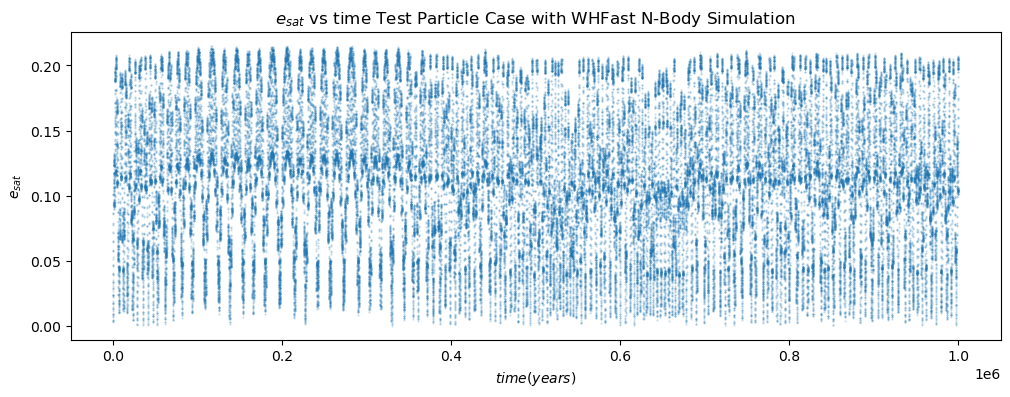

In [35]:
# e_sat vs period ratio graph
plt.subplots(figsize=(12, 4))
plt.title(r'$e_{sat}$ vs time Test Particle Case with WHFast N-Body Simulation')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$time (years)$')
plt.scatter(times/(2*np.pi), e_sat_test_n_body, s = 0.25, alpha = 0.25)
plt.show()

In [5]:
############### MASSIVE CASE #########################################
sim_full_n_body = rebound.Simulation()
sim_full_n_body.add(m=1, hash = "Sun")
sim_full_n_body.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim_full_n_body.add(m=m_sat,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim_full_n_body.move_to_com()

sat = sim_full_n_body.particles[2]
jup = sim_full_n_body.particles[1]

times = np.linspace(0,1e6,int(1e5))*2*np.pi
long_peri_sat_full_n_body = np.zeros(len(times))
e_sat_full_n_body = np.zeros(len(times))
a_sat_full_n_body = np.zeros(len(times))
p_sat_full_n_body = np.zeros(len(times))

long_peri_j_full_n_body = np.zeros(len(times))
e_j_full_n_body = np.zeros(len(times))
a_j_full_n_body = np.zeros(len(times))
p_j_full_n_body = np.zeros(len(times))

sim_full_n_body.init_megno()
e_i_full_n_body = sim_full_n_body.energy()

for i in tqdm(range(len(times))):
    sim_full_n_body.integrate(times[i])
    
    long_peri_sat_full_n_body[i] = sat.pomega
    e_sat_full_n_body[i] = sat.e
    a_sat_full_n_body[i] = sat.a
    p_sat_full_n_body[i] = sat.P

    long_peri_j_full_n_body[i] = jup.pomega
    e_j_full_n_body[i] = jup.e
    a_j_full_n_body[i] = jup.a
    p_j_full_n_body[i] = jup.P

e_f = sim_full_n_body.energy()
m_f = sim_full_n_body.megno()

e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100

print(f'Energy percent change: {e_per: .2e} %')
print(f'Final MEGNO value: {m_f: .2e}')

100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [01:38<00:00, 1014.45it/s]

Energy percent change:  1.82e+01 %
Final MEGNO value:  2.38e+02


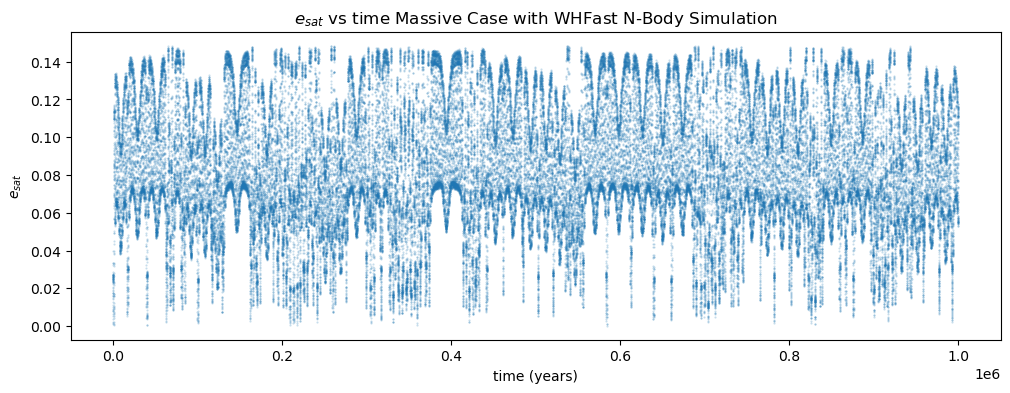

In [30]:
# e_sat vs period ratio graph
plt.subplots(figsize=(12, 4))
plt.title(r'$e_{sat}$ vs time Massive Case with WHFast N-Body Simulation')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'time (years)')
plt.scatter(times/(2*np.pi), e_sat_full_n_body, s = 0.25, alpha = 0.25)
plt.show()

## Celmech

In [12]:
############## FIRST ORDER MMR ################################

sim = rebound.Simulation()
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=1e-10,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

pvars = Poincare.from_Simulation(sim)

pham_1st_ord_MMR = PoincareHamiltonian(pvars)
pham_1st_ord_MMR.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham_1st_ord_MMR.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=1) 



times, pomega_sat_1st_ord_MMR, pomega_j_1st_ord_MMR, e_sat_1st_ord_MMR, a_sat_1st_ord_MMR, a_jup_1st_ord_MMR, lam_sat,lam_jup = hk_integrate(pham_1st_ord_MMR, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634816146e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:10<00:00, 9872.37it/s]

-8.880166634815167e-05
Energy Percent Change: 1.1018852470986615e-11 %
*** Simulation Complete ***
Time elapsed  = 10.133724790000088 seconds


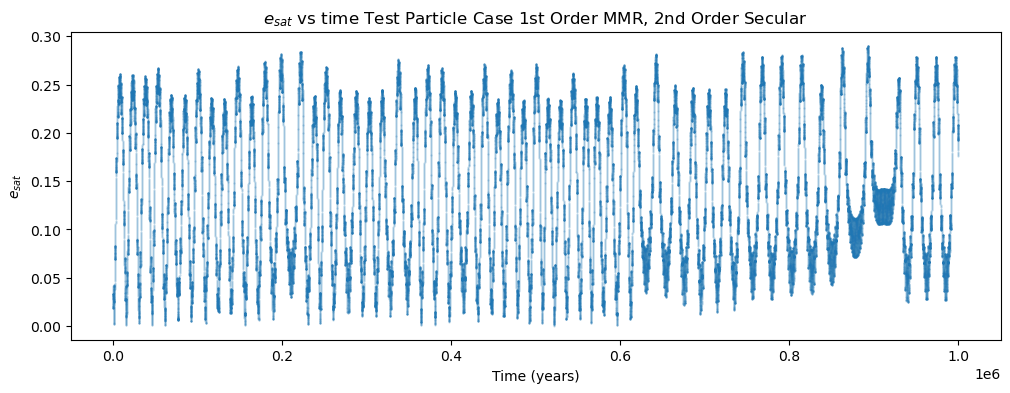

In [29]:
# e_sat vs period ratio graph
plt.subplots(figsize = (12,4))
plt.title(r'$e_{sat}$ vs time Test Particle Case 1st Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'Time (years)')
plt.scatter(times/(2*np.pi), e_sat_1st_ord_MMR, s = 0.25, alpha = 0.25)
plt.show()

In [15]:
#################### SECOND ORDER MMR ###########################
pham_2dn_ord_MMR = PoincareHamiltonian(pvars)
pham_2dn_ord_MMR.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham_2dn_ord_MMR.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=2) 

times, pomega_sat_2dn_ord_MMR, pomega_j_2dn_ord_MMR, e_sat_2dn_ord_MMR, a_sat_2dn_ord_MMR, a_jup_2dn_ord_MMR, lam_sat,lam_jup = hk_integrate(pham_2dn_ord_MMR, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634823682e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:12<00:00, 7818.12it/s]

-8.880166634822883e-05
Energy Percent Change: 9.004325426421863e-12 %
*** Simulation Complete ***
Time elapsed  = 12.795311535999645 seconds


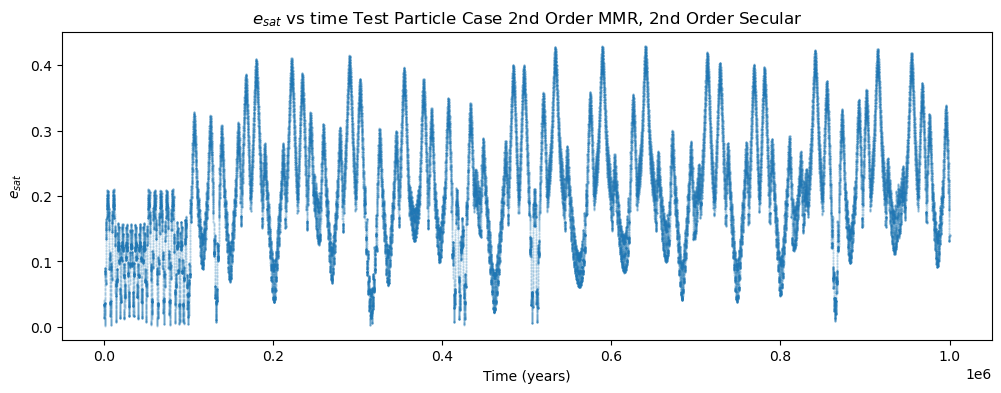

In [31]:
# e_sat vs period ratio graph
plt.subplots(figsize = (12,4))
plt.title(r'$e_{sat}$ vs time Test Particle Case 2nd Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'Time (years)')
plt.scatter(times/(2*np.pi), e_sat_2dn_ord_MMR, s = 0.25, alpha = 0.25)
plt.show()

In [17]:
##################### THIRD ORDER MMR ####################################
pham_3rd_ord_MMR = PoincareHamiltonian(pvars)
pham_3rd_ord_MMR.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham_3rd_ord_MMR.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=3) 

times, pomega_sat_3rd_ord_MMR, pomega_j_3rd_ord_MMR, e_sat_3rd_ord_MMR, a_sat_3rd_ord_MMR, a_jup_3rd_ord_MMR, sat_lam, jup_lam = hk_integrate(pham_3rd_ord_MMR, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634824185e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:30<00:00, 3319.08it/s]

-8.880166634822767e-05
Energy Percent Change: 1.5963600671248704e-11 %
*** Simulation Complete ***
Time elapsed  = 30.13320165799996 seconds


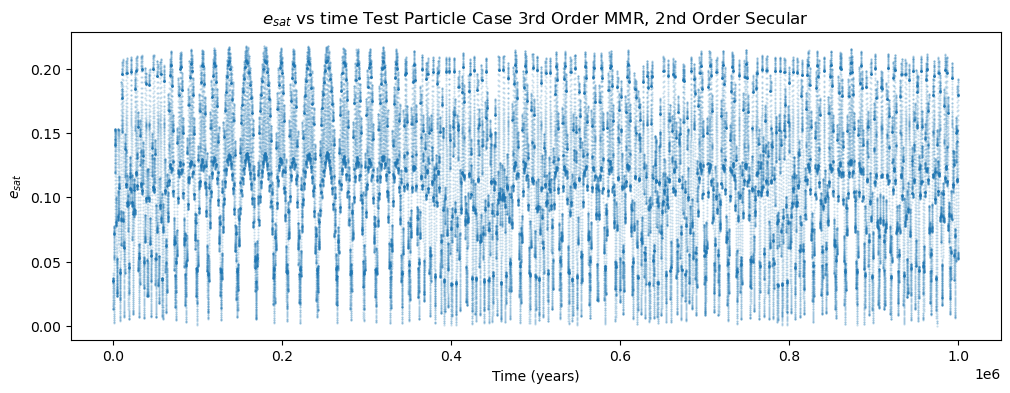

In [32]:
# e_sat vs period ratio graph
plt.subplots(figsize = (12,4))
plt.title(r'$e_{sat}$ vs time Test Particle Case 3rd Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'Time (years)')
plt.scatter(times/(2*np.pi), e_sat_3rd_ord_MMR, s = 0.25, alpha = 0.25)
plt.show()

In [20]:
########################### FOURTH ORDER MMR ##############################
pham_4th_ord_MMR = PoincareHamiltonian(pvars)
pham_4th_ord_MMR.add_secular_terms(indexIn=1, indexOut=2, max_order=2)
pham_4th_ord_MMR.add_MMR_terms(p=2,q=1,indexIn=1, indexOut=2, max_order=4) 

times, pomega_sat_4th_ord_MMR, pomega_j_4th_ord_MMR, e_sat_4th_ord_MMR, a_sat_4th_ord_MMR, a_jup_4th_ord_MMR, lam_sat, lam_j = hk_integrate(pham_4th_ord_MMR, 1e6, 1e5)

['Lambda1', 'Lambda2', 'eta1', 'eta2', 'kappa1', 'kappa2', 'lambda1', 'lambda2']
*** Differentiating  ***
-8.880166634824106e-05
*** Starting Simulation ***


100%|█████████████████████████████████████████████████████████████████████████| 100000/100000 [00:57<00:00, 1729.68it/s]

-8.88016663482396e-05
Energy Percent Change: 1.6482494000907031e-12 %
*** Simulation Complete ***
Time elapsed  = 57.82118004999984 seconds


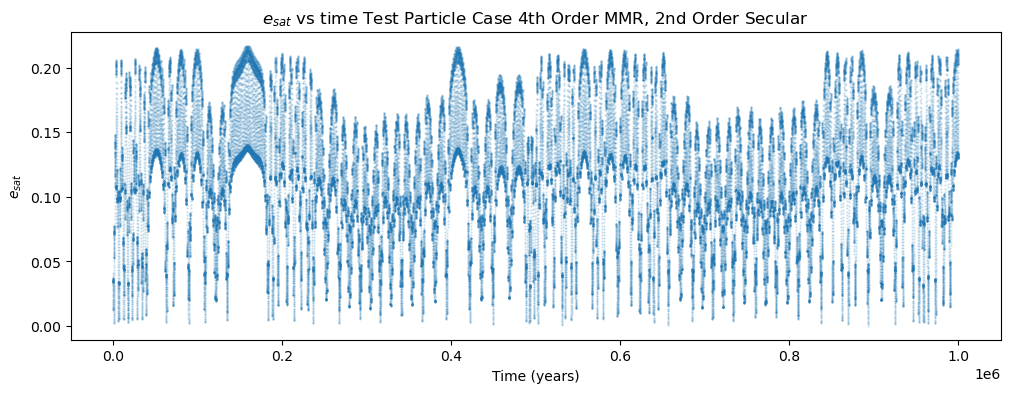

In [33]:
# e_sat vs period ratio graph
plt.subplots(figsize = (12,4))
plt.title(r'$e_{sat}$ vs time Test Particle Case 4th Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'Time (years)')
plt.scatter(times/(2*np.pi), e_sat_4th_ord_MMR, s = 0.25, alpha = 0.25)
plt.show()

# shorter time period for the time series

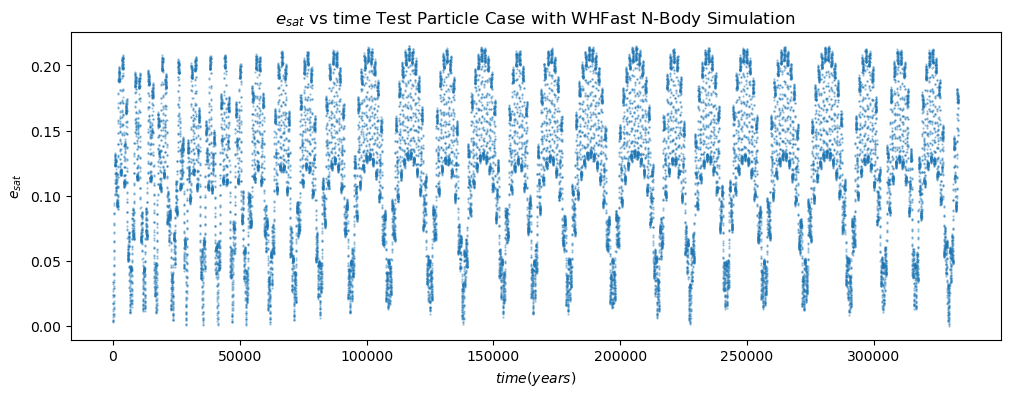

In [36]:
# e_sat vs period ratio graph
plt.subplots(figsize=(12, 4))
plt.title(r'$e_{sat}$ vs time Test Particle Case with WHFast N-Body Simulation')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'$time (years)$')
plt.scatter(times[0:int(len(times)/3)]/(2*np.pi), e_sat_test_n_body[0:int(len(times)/3)], s = 0.4, alpha = 0.4)
plt.show()

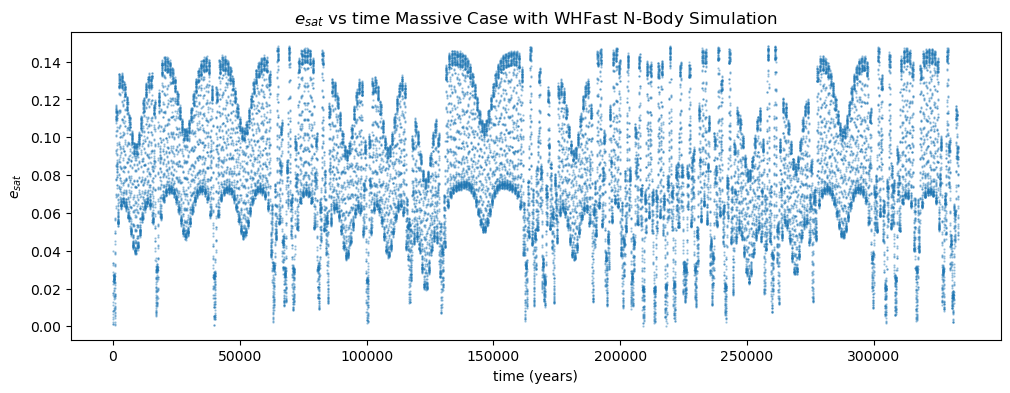

In [37]:
# e_sat vs period ratio graph
plt.subplots(figsize=(12, 4))
plt.title(r'$e_{sat}$ vs time Massive Case with WHFast N-Body Simulation')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'time (years)')
plt.scatter(times[0:int(len(times)/3)]/(2*np.pi), e_sat_full_n_body[0:int(len(times)/3)], s = 0.4, alpha = 0.4)
plt.show()

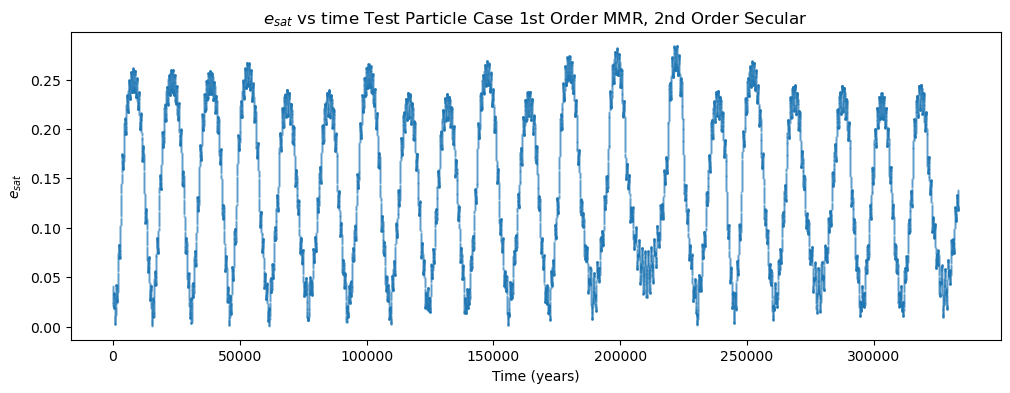

In [38]:
# e_sat vs period ratio graph
plt.subplots(figsize = (12,4))
plt.title(r'$e_{sat}$ vs time Test Particle Case 1st Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'Time (years)')
plt.scatter(times[0:int(len(times)/3)]/(2*np.pi), e_sat_1st_ord_MMR[0:int(len(times)/3)], s = 0.4, alpha = 0.4)
plt.show()

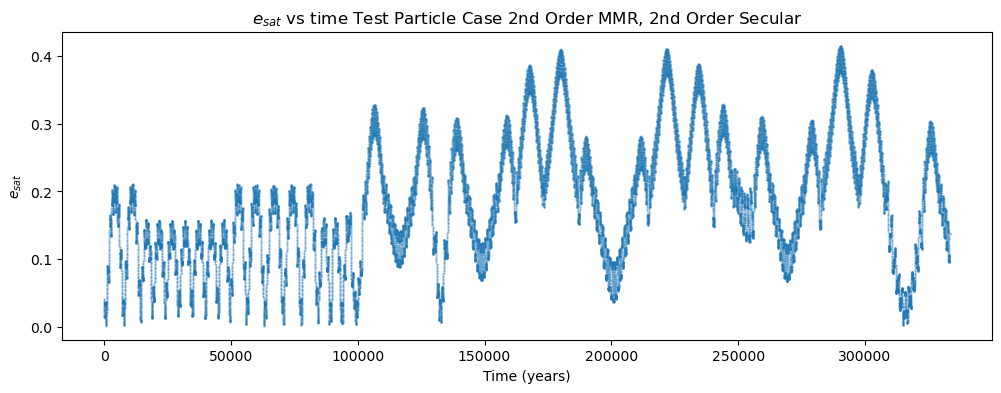

In [40]:
# e_sat vs period ratio graph
plt.subplots(figsize = (12,4))
plt.title(r'$e_{sat}$ vs time Test Particle Case 2nd Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'Time (years)')
plt.scatter(times[0:int(len(times)/3)]/(2*np.pi), e_sat_2dn_ord_MMR[0:int(len(times)/3)], s = 0.4, alpha = 0.4)
plt.show()

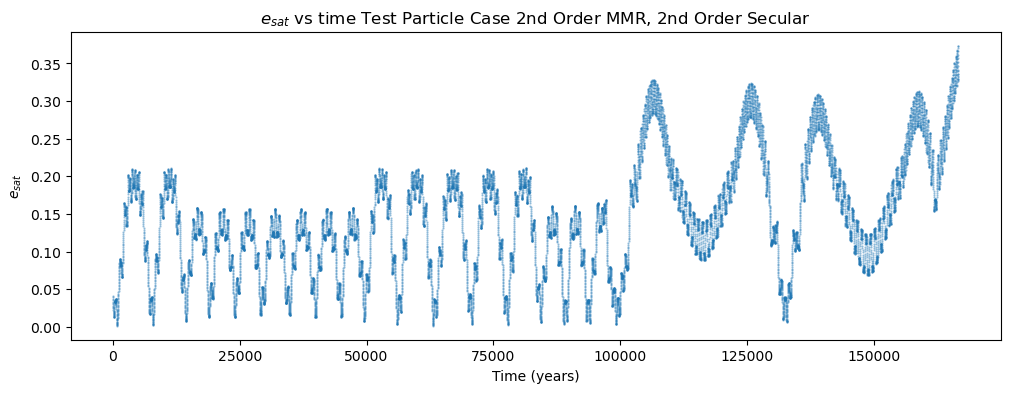

In [43]:
# e_sat vs period ratio graph
plt.subplots(figsize = (12,4))
plt.title(r'$e_{sat}$ vs time Test Particle Case 2nd Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'Time (years)')
plt.scatter(times[0:int(len(times)/6)]/(2*np.pi), e_sat_2dn_ord_MMR[0:int(len(times)/6)], s = 0.4, alpha = 0.4)
plt.show()

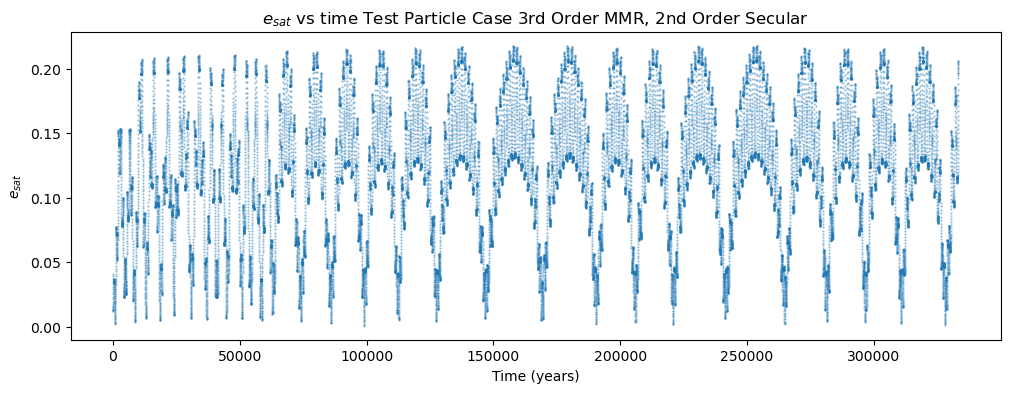

In [41]:
# e_sat vs period ratio graph
plt.subplots(figsize = (12,4))
plt.title(r'$e_{sat}$ vs time Test Particle Case 3rd Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'Time (years)')
plt.scatter(times[0:int(len(times)/3)]/(2*np.pi), e_sat_3rd_ord_MMR[0:int(len(times)/3)], s = 0.4, alpha = 0.4)
plt.show()

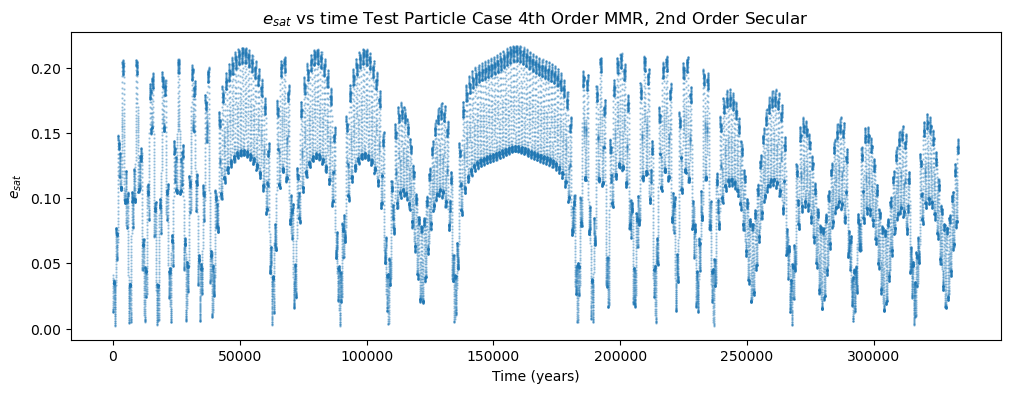

In [42]:
# e_sat vs period ratio graph
plt.subplots(figsize = (12,4))
plt.title(r'$e_{sat}$ vs time Test Particle Case 4th Order MMR, 2nd Order Secular')
plt.ylabel(r'$e_{sat}$')
plt.xlabel(r'Time (years)')
plt.scatter(times[0:int(len(times)/3)]/(2*np.pi), e_sat_4th_ord_MMR[0:int(len(times)/3)], s = 0.4, alpha = 0.4)
plt.show()